# Refinement Process Metrics Analysis

This notebook analyzes the feedback refinement process from the MRBench v3 devset.


In [1]:
# Import required libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the refinement data
data = []
with open('outputs/mrbench_v3_devset_refinements.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

print(f"Total conversations loaded: {len(data)}")

Total conversations loaded: 2476


## 1. Iteration Statistics


In [3]:
# Calculate iteration statistics
iteration_counts = [len(conv['iterations']) for conv in data]
completed_status = [conv['completed'] for conv in data]

# Create summary dataframe
iteration_stats = pd.DataFrame({
    'num_iterations': iteration_counts,
    'completed': completed_status
})

# Overall statistics
print("=" * 60)
print("ITERATION STATISTICS")
print("=" * 60)
print(f"\nTotal conversations: {len(data)}")
print(f"Completed refinements: {sum(completed_status)} ({sum(completed_status)/len(data)*100:.1f}%)")
print(f"Not completed: {len(data) - sum(completed_status)} ({(len(data) - sum(completed_status))/len(data)*100:.1f}%)")
print(f"\nAverage iterations: {np.mean(iteration_counts):.2f}")
print(f"Median iterations: {np.median(iteration_counts):.0f}")
print(f"Min iterations: {np.min(iteration_counts)}")
print(f"Max iterations: {np.max(iteration_counts)}")
print(f"Std deviation: {np.std(iteration_counts):.2f}")

# Iteration distribution
print(f"\nIteration distribution:")
iter_dist = Counter(iteration_counts)
for num_iter in sorted(iter_dist.keys()):
    count = iter_dist[num_iter]
    print(f"  {num_iter} iteration(s): {count} conversations ({count/len(data)*100:.1f}%)")

ITERATION STATISTICS

Total conversations: 2476
Completed refinements: 2089 (84.4%)
Not completed: 387 (15.6%)

Average iterations: 1.94
Median iterations: 2
Min iterations: 1
Max iterations: 3
Std deviation: 0.76

Iteration distribution:
  1 iteration(s): 788 conversations (31.8%)
  2 iteration(s): 1052 conversations (42.5%)
  3 iteration(s): 636 conversations (25.7%)


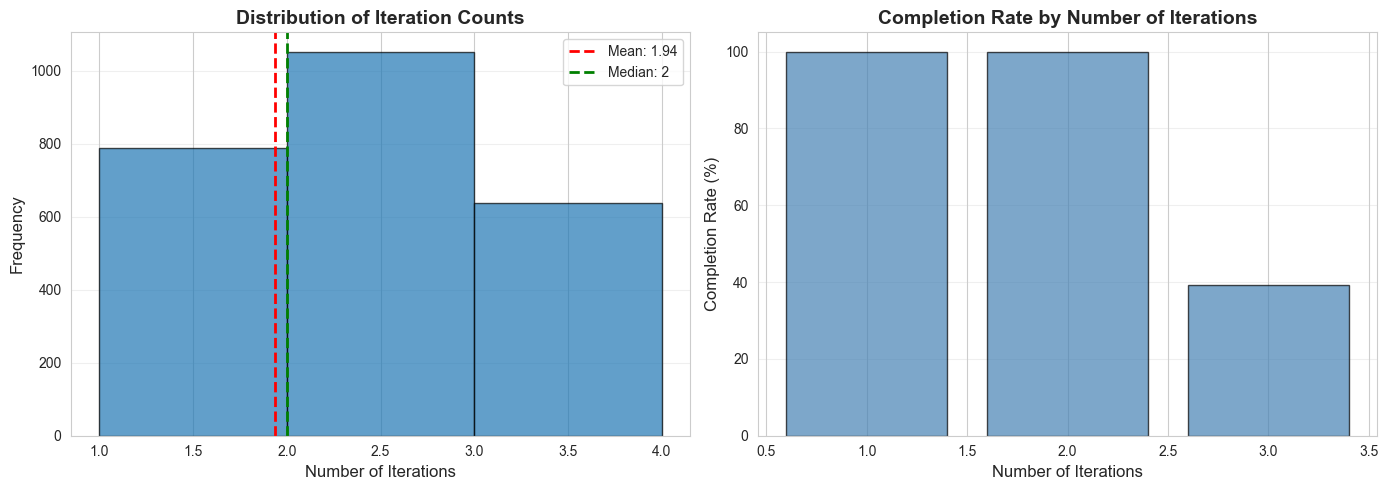

In [4]:
# Visualization: Iteration distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(iteration_counts, bins=range(1, max(iteration_counts)+2), edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(iteration_counts), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(iteration_counts):.2f}')
axes[0].axvline(np.median(iteration_counts), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(iteration_counts):.0f}')
axes[0].set_xlabel('Number of Iterations', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Iteration Counts', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Completion status by iterations
completed_by_iter = iteration_stats.groupby('num_iterations')['completed'].agg(['sum', 'count'])
completed_by_iter['completion_rate'] = (completed_by_iter['sum'] / completed_by_iter['count'] * 100)
completed_by_iter.reset_index(inplace=True)

axes[1].bar(completed_by_iter['num_iterations'], completed_by_iter['completion_rate'], 
            edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Number of Iterations', fontsize=12)
axes[1].set_ylabel('Completion Rate (%)', fontsize=12)
axes[1].set_title('Completion Rate by Number of Iterations', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Predicted Labels Analysis


In [5]:
# Extract predicted labels from BD predictions (final iteration)
bd_tasks = ['Mistake Identification (includes the relevant mistake identification)',
            'Mistake Location (points to the mistake\'s location in the answer and outline what the error is to help the student remediate)',
            'Actionability (provides what the student should do next)']

final_predictions = {task: [] for task in bd_tasks}
final_predictions['Providing Guidance (should provide the student with relevant and helpful guidance)'] = []

for conv in data:
    final_pred = conv['predictions']
    
    # BD predictions
    for task in bd_tasks:
        if task in final_pred['bd_predictions']:
            final_predictions[task].append(final_pred['bd_predictions'][task]['predicted_label'])

    # Guidance prediction
    if 'ialabuc_prediction' in final_pred:
        final_predictions['Providing Guidance (should provide the student with relevant and helpful guidance)'].append(final_pred['ialabuc_prediction']['predicted_label'])

# Calculate label distributions
print("=" * 60)
print("FINAL PREDICTED LABELS DISTRIBUTION")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    if final_predictions[task]:
        label_counts = Counter(final_predictions[task])
        total = len(final_predictions[task])
        for label in ['Yes', 'To some extent', 'No']:
            count = label_counts.get(label, 0)
            print(f"  {label}: {count} ({count/total*100:.1f}%)")

FINAL PREDICTED LABELS DISTRIBUTION

Mistake Identification (includes the relevant mistake identification):
  Yes: 2423 (97.9%)
  To some extent: 5 (0.2%)
  No: 48 (1.9%)

Mistake Location (points to the mistake's location in the answer and outline what the error is to help the student remediate):
  Yes: 2308 (93.2%)
  To some extent: 45 (1.8%)
  No: 123 (5.0%)

Actionability (provides what the student should do next):
  Yes: 2250 (90.9%)
  To some extent: 63 (2.5%)
  No: 163 (6.6%)

Providing Guidance (should provide the student with relevant and helpful guidance):
  Yes: 2392 (96.6%)
  To some extent: 71 (2.9%)
  No: 13 (0.5%)


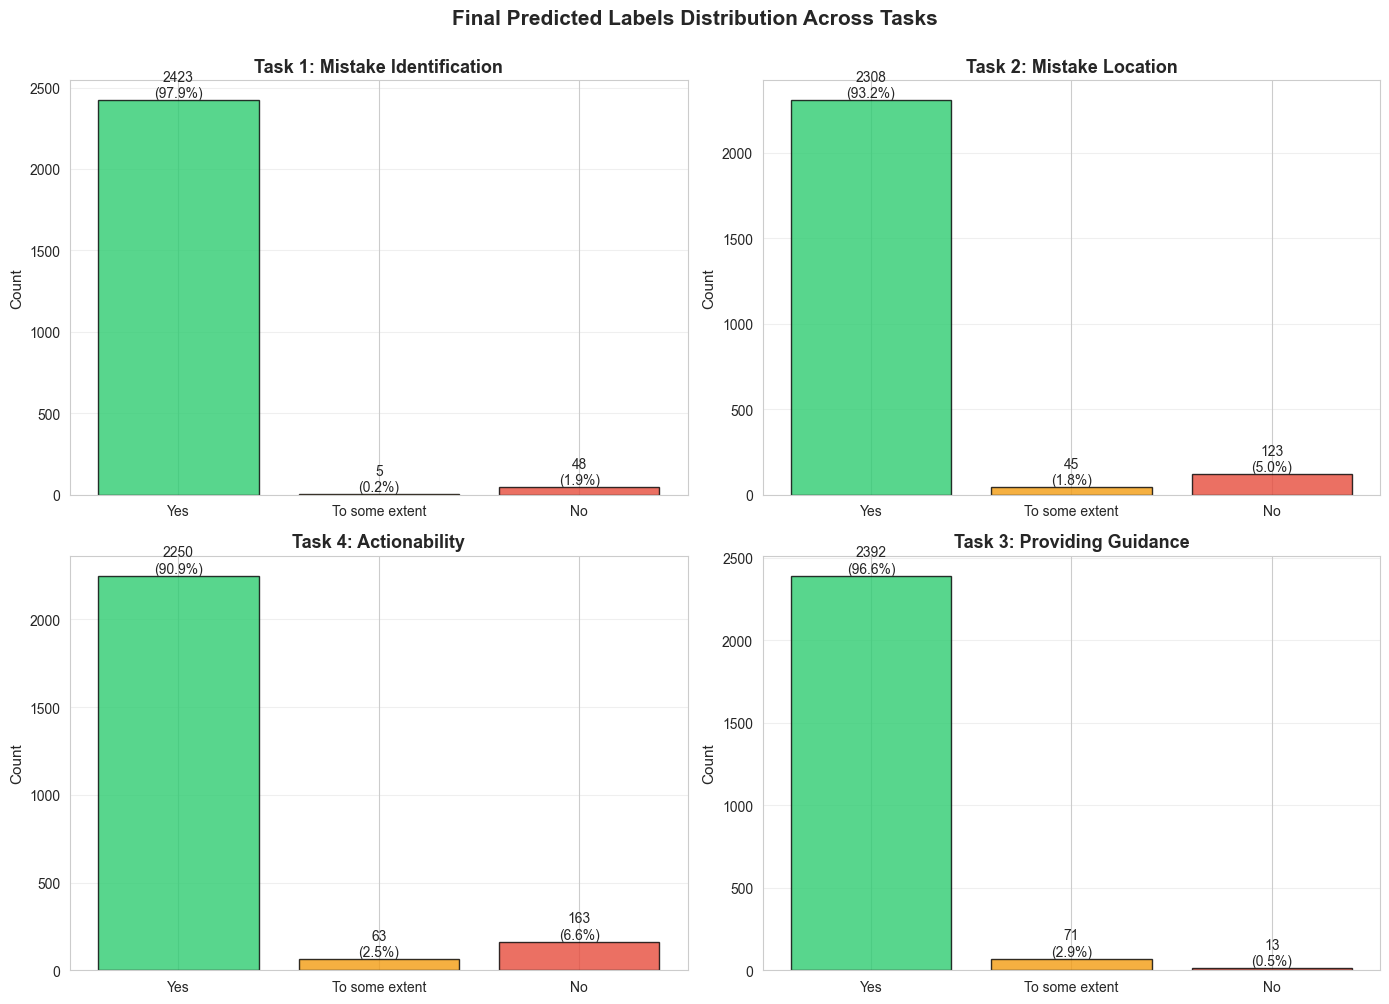

In [6]:
# Visualization: Label distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

task_names_short = ['Task 1: Mistake Identification', 'Task 2: Mistake Location', 'Task 4: Actionability', 'Task 3: Providing Guidance']
all_tasks = bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']

for idx, (task, short_name) in enumerate(zip(all_tasks, task_names_short)):
    if final_predictions[task]:
        label_counts = Counter(final_predictions[task])
        labels = ['Yes', 'To some extent', 'No']
        counts = [label_counts.get(label, 0) for label in labels]
        colors = ['#2ecc71', '#f39c12', '#e74c3c']
        
        bars = axes[idx].bar(labels, counts, color=colors, edgecolor='black', alpha=0.8)
        axes[idx].set_ylabel('Count', fontsize=11)
        axes[idx].set_title(short_name, fontsize=13, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add percentage labels
        total = sum(counts)
        for bar, count in zip(bars, counts):
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{count}\n({count/total*100:.1f}%)',
                          ha='center', va='bottom', fontsize=10)

plt.suptitle('Final Predicted Labels Distribution Across Tasks', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 3. Label Evolution Across Iterations


In [7]:
# Track label changes across iterations
label_changes = {task: defaultdict(int) for task in bd_tasks}
label_changes['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(int)

for conv in data:
    iterations = conv['iterations']
    if len(iterations) > 1:
        for i in range(len(iterations) - 1):
            curr_iter = iterations[i]['predictions']
            next_iter = iterations[i + 1]['predictions']
            
            # BD predictions
            for task in bd_tasks:
                if task in curr_iter['bd_predictions'] and task in next_iter['bd_predictions']:
                    curr_label = curr_iter['bd_predictions'][task]['predicted_label']
                    next_label = next_iter['bd_predictions'][task]['predicted_label']
                    
                    if curr_label != next_label:
                        transition = f"{curr_label} → {next_label}"
                        label_changes[task][transition] += 1
            
            # IALab prediction
            if 'ialabuc_prediction' in curr_iter and 'ialabuc_prediction' in next_iter:
                curr_label = curr_iter['ialabuc_prediction']['predicted_label']
                next_label = next_iter['ialabuc_prediction']['predicted_label']
                
                if curr_label != next_label:
                    transition = f"{curr_label} → {next_label}"
                    label_changes['Providing Guidance (should provide the student with relevant and helpful guidance)'][transition] += 1

# Display label changes
print("=" * 60)
print("TOTAL LABEL CHANGES ACROSS ITERATIONS")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    if label_changes[task]:
        total_changes = sum(label_changes[task].values())
        print(f"  Total label changes: {total_changes}")
        for transition, count in sorted(label_changes[task].items(), key=lambda x: x[1], reverse=True):
            print(f"    {transition}: {count} times")
    else:
        print("  No label changes observed")

TOTAL LABEL CHANGES ACROSS ITERATIONS

Mistake Identification (includes the relevant mistake identification):
  Total label changes: 555
    No → Yes: 353 times
    To some extent → Yes: 140 times
    Yes → No: 39 times
    To some extent → No: 11 times
    Yes → To some extent: 8 times
    No → To some extent: 4 times

Mistake Location (points to the mistake's location in the answer and outline what the error is to help the student remediate):
  Total label changes: 802
    No → Yes: 579 times
    To some extent → Yes: 137 times
    Yes → No: 60 times
    No → To some extent: 12 times
    Yes → To some extent: 7 times
    To some extent → No: 7 times

Actionability (provides what the student should do next):
  Total label changes: 1227
    No → Yes: 674 times
    To some extent → Yes: 299 times
    Yes → No: 118 times
    Yes → To some extent: 51 times
    To some extent → No: 43 times
    No → To some extent: 42 times

Providing Guidance (should provide the student with relevant and 

In [8]:
# Track label changes across iterations (overall + by iteration step)
label_changes = {task: defaultdict(int) for task in bd_tasks}
label_changes['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(int)

label_changes_by_step = {task: defaultdict(lambda: defaultdict(int)) for task in bd_tasks}
label_changes_by_step['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(lambda: defaultdict(int))

for conv in data:
    iterations = conv['iterations']
    if len(iterations) > 1:
        for i in range(len(iterations) - 1):
            curr_iter = iterations[i]['predictions']
            next_iter = iterations[i + 1]['predictions']
            step_key = (i + 1, i + 2)

            # BD predictions
            for task in bd_tasks:
                if task in curr_iter['bd_predictions'] and task in next_iter['bd_predictions']:
                    curr_label = curr_iter['bd_predictions'][task]['predicted_label']
                    next_label = next_iter['bd_predictions'][task]['predicted_label']

                    if curr_label != next_label:
                        transition = f"{curr_label} → {next_label}"
                        label_changes[task][transition] += 1
                        label_changes_by_step[task][step_key][transition] += 1

            # IALab prediction
            if 'ialabuc_prediction' in curr_iter and 'ialabuc_prediction' in next_iter:
                curr_label = curr_iter['ialabuc_prediction']['predicted_label']
                next_label = next_iter['ialabuc_prediction']['predicted_label']

                if curr_label != next_label:
                    transition = f"{curr_label} → {next_label}"
                    guidance_task = 'Providing Guidance (should provide the student with relevant and helpful guidance)'
                    label_changes[guidance_task][transition] += 1
                    label_changes_by_step[guidance_task][step_key][transition] += 1

# Display label changes
print("=" * 60)
print("LABEL CHANGES ACROSS ITERATIONS")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    if label_changes[task]:
        total_changes = sum(label_changes[task].values())
        print(f"  Total label changes: {total_changes}")
        print("  Changes by iteration step:")

        for step_key in sorted(label_changes_by_step[task].keys()):
            step_total = sum(label_changes_by_step[task][step_key].values())
            print(f"    Iteration {step_key[0]} → {step_key[1]}: {step_total} change(s)")
            for transition, count in sorted(label_changes_by_step[task][step_key].items(), key=lambda x: x[1], reverse=True):
                print(f"      {transition}: {count} times")

        print("  Overall transitions:")
        for transition, count in sorted(label_changes[task].items(), key=lambda x: x[1], reverse=True):
            print(f"    {transition}: {count} times")
    else:
        print("  No label changes observed")

LABEL CHANGES ACROSS ITERATIONS

Mistake Identification (includes the relevant mistake identification):
  Total label changes: 555
  Changes by iteration step:
    Iteration 1 → 2: 483 change(s)
      No → Yes: 311 times
      To some extent → Yes: 134 times
      Yes → No: 20 times
      To some extent → No: 8 times
      Yes → To some extent: 7 times
      No → To some extent: 3 times
    Iteration 2 → 3: 72 change(s)
      No → Yes: 42 times
      Yes → No: 19 times
      To some extent → Yes: 6 times
      To some extent → No: 3 times
      Yes → To some extent: 1 times
      No → To some extent: 1 times
  Overall transitions:
    No → Yes: 353 times
    To some extent → Yes: 140 times
    Yes → No: 39 times
    To some extent → No: 11 times
    Yes → To some extent: 8 times
    No → To some extent: 4 times

Mistake Location (points to the mistake's location in the answer and outline what the error is to help the student remediate):
  Total label changes: 802
  Changes by iteration

In [11]:
# Sankey diagrams for CHANGES ONLY with explicit iteration stages (1 -> 2 -> 3)
import plotly.graph_objects as go

# Define task display names
task_display_names = {
    'Mistake Identification (includes the relevant mistake identification)': 'Task 1: Mistake Identification',
    'Mistake Location (points to the mistake\'s location in the answer and outline what the error is to help the student remediate)': 'Task 2: Mistake Location',
    'Actionability (provides what the student should do next)': 'Task 4: Actionability',
    'Providing Guidance (should provide the student with relevant and helpful guidance)': 'Task 3: Providing Guidance'
}

label_options = ['Yes', 'To some extent', 'No']
all_tasks = bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']

for task in all_tasks:
    task_steps = label_changes_by_step[task]
    if not task_steps:
        continue

    task_short = task_display_names.get(task, task.split('(')[0].strip())

    # Build nodes for 3 columns: Iteration 1, Iteration 2, Iteration 3
    # Node labels contain only class names; iteration appears once as a column header.
    nodes = label_options + label_options + label_options

    sources = []
    targets = []
    values = []
    colors = []

    # Helper: style transition color
    def transition_color(source_label, target_label, alpha=0.45):
        if source_label == 'To some extent' and target_label == 'No':
            return f'rgba(231, 76, 60, {alpha})'    # red (to some extent -> no)
        if source_label == 'No' and target_label == 'To some extent':
            return f'rgba(243, 156, 18, {alpha})'   # orange (no -> to some extent)
        if source_label == 'No' and target_label == 'Yes':
            return f'rgba(46, 204, 113, {alpha})'   # green (strong improvement)
        if source_label == 'To some extent' and target_label == 'Yes':
            return f'rgba(46, 204, 113, {alpha})'   # green (improvement)
        if source_label == 'Yes' and target_label in ['To some extent', 'No']:
            return f'rgba(231, 76, 60, {alpha})'    # red (degradation)
        return f'rgba(52, 152, 219, {alpha})'       # lateral change

    # Iteration 1 -> Iteration 2 (changes only)
    for src_label in label_options:
        for tgt_label in label_options:
            if src_label == tgt_label:
                continue
            transition = f"{src_label} → {tgt_label}"
            count = task_steps.get((1, 2), {}).get(transition, 0)
            if count > 0:
                sources.append(label_options.index(src_label))
                targets.append(3 + label_options.index(tgt_label))
                values.append(count)
                colors.append(transition_color(src_label, tgt_label, alpha=0.50))

    # Iteration 2 -> Iteration 3 (changes only)
    for src_label in label_options:
        for tgt_label in label_options:
            if src_label == tgt_label:
                continue
            transition = f"{src_label} → {tgt_label}"
            count = task_steps.get((2, 3), {}).get(transition, 0)
            if count > 0:
                sources.append(3 + label_options.index(src_label))
                targets.append(6 + label_options.index(tgt_label))
                values.append(count)
                colors.append(transition_color(src_label, tgt_label, alpha=0.35))

    if not values:
        continue

    step12_total = sum(task_steps.get((1, 2), {}).values())
    step23_total = sum(task_steps.get((2, 3), {}).values())

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=20,
            thickness=24,
            line=dict(color='black', width=0.5),
            label=nodes,
            color=['#2ecc71', '#f39c12', '#e74c3c'] * 3
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            hovertemplate='%{source.label} → %{target.label}<br>Count: %{value}<extra></extra>'
        )
    )])

    fig.update_layout(
        title=(
            f"{task_short}<br>"
            f"<sub>Iteration 1→2: {step12_total} changes | Iteration 2→3: {step23_total} changes</sub>"
        ),
        annotations=[
            dict(x=0.0, y=-0.09, xref='paper', yref='paper', text='Iteration 1', showarrow=False, font=dict(size=18)),
            dict(x=0.50, y=-0.09, xref='paper', yref='paper', text='Iteration 2', showarrow=False, font=dict(size=18)),
            dict(x=1, y=-0.09, xref='paper', yref='paper', text='Iteration 3', showarrow=False, font=dict(size=18)),
        ],
        font=dict(size=22),
        height=450,
        width=1000,
        showlegend=False,
        margin=dict(l=40, r=40, t=120, b=40)
    )

    fig.show()

In [8]:
# Track ALL label transitions across iterations (including no-change transitions)
all_label_transitions = {task: defaultdict(int) for task in bd_tasks}
all_label_transitions['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(int)

all_label_transitions_by_step = {task: defaultdict(lambda: defaultdict(int)) for task in bd_tasks}
all_label_transitions_by_step['Providing Guidance (should provide the student with relevant and helpful guidance)'] = defaultdict(lambda: defaultdict(int))

for conv in data:
    iterations = conv['iterations']
    if len(iterations) > 1:
        for i in range(len(iterations) - 1):
            curr_iter = iterations[i]['predictions']
            next_iter = iterations[i + 1]['predictions']
            step_key = (i + 1, i + 2)

            # BD predictions (count all transitions, even when label does not change)
            for task in bd_tasks:
                if task in curr_iter['bd_predictions'] and task in next_iter['bd_predictions']:
                    curr_label = curr_iter['bd_predictions'][task]['predicted_label']
                    next_label = next_iter['bd_predictions'][task]['predicted_label']
                    transition = f"{curr_label} → {next_label}"
                    all_label_transitions[task][transition] += 1
                    all_label_transitions_by_step[task][step_key][transition] += 1

            # IALab prediction (count all transitions, even when label does not change)
            if 'ialabuc_prediction' in curr_iter and 'ialabuc_prediction' in next_iter:
                curr_label = curr_iter['ialabuc_prediction']['predicted_label']
                next_label = next_iter['ialabuc_prediction']['predicted_label']
                transition = f"{curr_label} → {next_label}"
                guidance_task = 'Providing Guidance (should provide the student with relevant and helpful guidance)'
                all_label_transitions[guidance_task][transition] += 1
                all_label_transitions_by_step[guidance_task][step_key][transition] += 1

# Display all transitions
print("=" * 60)
print("ALL LABEL TRANSITIONS ACROSS ITERATIONS (INCLUDING NO CHANGE)")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    if all_label_transitions[task]:
        total_transitions = sum(all_label_transitions[task].values())
        print(f"  Total transitions: {total_transitions}")
        print("  Transitions by iteration step:")

        for step_key in sorted(all_label_transitions_by_step[task].keys()):
            step_total = sum(all_label_transitions_by_step[task][step_key].values())
            print(f"    Iteration {step_key[0]} → {step_key[1]}: {step_total} transition(s)")
            for transition, count in sorted(all_label_transitions_by_step[task][step_key].items(), key=lambda x: x[1], reverse=True):
                print(f"      {transition}: {count} times")

        print("  Overall transitions:")
        for transition, count in sorted(all_label_transitions[task].items(), key=lambda x: x[1], reverse=True):
            print(f"    {transition}: {count} times")
    else:
        print("  No transitions observed")

ALL LABEL TRANSITIONS ACROSS ITERATIONS (INCLUDING NO CHANGE)

Mistake Identification (includes the relevant mistake identification):
  Total transitions: 2324
  Transitions by iteration step:
    Iteration 1 → 2: 1688 transition(s)
      Yes → Yes: 1162 times
      No → Yes: 311 times
      To some extent → Yes: 134 times
      No → No: 41 times
      Yes → No: 20 times
      To some extent → No: 8 times
      Yes → To some extent: 7 times
      No → To some extent: 3 times
      To some extent → To some extent: 2 times
    Iteration 2 → 3: 636 transition(s)
      Yes → Yes: 535 times
      No → Yes: 42 times
      No → No: 26 times
      Yes → No: 19 times
      To some extent → Yes: 6 times
      To some extent → To some extent: 3 times
      To some extent → No: 3 times
      Yes → To some extent: 1 times
      No → To some extent: 1 times
  Overall transitions:
    Yes → Yes: 1697 times
    No → Yes: 353 times
    To some extent → Yes: 140 times
    No → No: 67 times
    Yes → No:

In [9]:
# Sankey diagrams for ALL transitions with explicit iteration stages (1 -> 2 -> 3)
import plotly.graph_objects as go

# Define task display names
task_display_names = {
    'Mistake Identification (includes the relevant mistake identification)': 'Task 1: Mistake Identification',
    'Mistake Location (points to the mistake\'s location in the answer and outline what the error is to help the student remediate)': 'Task 2: Mistake Location',
    'Actionability (provides what the student should do next)': 'Task 4: Actionability',
    'Providing Guidance (should provide the student with relevant and helpful guidance)': 'Task 3: Providing Guidance'
}

label_options = ['Yes', 'To some extent', 'No']
all_tasks = bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']

for task in all_tasks:
    task_steps = all_label_transitions_by_step[task]
    if not task_steps:
        continue

    task_short = task_display_names.get(task, task.split('(')[0].strip())

    # Build nodes for 3 columns: Iteration 1, Iteration 2, Iteration 3
    nodes = (
        [f"{label}<br>(Iteration 1)" for label in label_options] +
        [f"{label}<br>(Iteration 2)" for label in label_options] +
        [f"{label}<br>(Iteration 3)" for label in label_options]
    )

    sources = []
    targets = []
    values = []
    colors = []

    # Helper: style transition color
    def transition_color(source_label, target_label, alpha=0.45):
        if source_label == target_label:
            return f'rgba(120, 120, 120, {alpha})'  # no-change
        if source_label == 'No' and target_label in ['To some extent', 'Yes']:
            return f'rgba(46, 204, 113, {alpha})'   # improvement
        if source_label == 'To some extent' and target_label == 'Yes':
            return f'rgba(46, 204, 113, {alpha})'   # improvement
        if source_label == 'Yes' and target_label in ['To some extent', 'No']:
            return f'rgba(231, 76, 60, {alpha})'    # degradation
        return f'rgba(52, 152, 219, {alpha})'       # lateral mix

    # Iteration 1 -> Iteration 2
    for src_label in label_options:
        for tgt_label in label_options:
            transition = f"{src_label} → {tgt_label}"
            count = task_steps.get((1, 2), {}).get(transition, 0)
            if count > 0:
                sources.append(label_options.index(src_label))
                targets.append(3 + label_options.index(tgt_label))
                values.append(count)
                colors.append(transition_color(src_label, tgt_label, alpha=0.50))

    # Iteration 2 -> Iteration 3
    for src_label in label_options:
        for tgt_label in label_options:
            transition = f"{src_label} → {tgt_label}"
            count = task_steps.get((2, 3), {}).get(transition, 0)
            if count > 0:
                sources.append(3 + label_options.index(src_label))
                targets.append(6 + label_options.index(tgt_label))
                values.append(count)
                colors.append(transition_color(src_label, tgt_label, alpha=0.35))

    if not values:
        continue

    step12_total = sum(task_steps.get((1, 2), {}).values())
    step23_total = sum(task_steps.get((2, 3), {}).values())

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=20,
            thickness=24,
            line=dict(color='black', width=0.5),
            label=nodes,
            color=['#2ecc71', '#f39c12', '#e74c3c'] * 3
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors,
            hovertemplate='%{source.label} → %{target.label}<br>Count: %{value}<extra></extra>'
        )
    )])

    fig.update_layout(
        title=(
            f"{task_short}<br>"
            f"<sub>Iteration 1→2 transitions: {step12_total} | Iteration 2→3 transitions: {step23_total}</sub>"
        ),
        font=dict(size=11),
        height=600,
        width=1050,
        showlegend=False,
        margin=dict(l=40, r=40, t=95, b=40)
    )

    fig.show()

## 4. Probability Analysis


In [9]:
# Analyze probability scores for final predictions
prob_data = {task: {'Yes': [], 'To some extent': [], 'No': []} for task in bd_tasks}
prob_data['Providing Guidance (should provide the student with relevant and helpful guidance)'] = {'Yes': [], 'To some extent': [], 'No': []}

for conv in data:
    final_pred = conv['predictions']
    
    # BD predictions
    for task in bd_tasks:
        if task in final_pred['bd_predictions']:
            probs = final_pred['bd_predictions'][task]['probabilities']
            for label in ['Yes', 'To some extent', 'No']:
                if label in probs:
                    prob_data[task][label].append(probs[label])
    
    # IALab prediction
    if 'ialabuc_prediction' in final_pred:
        probs = final_pred['ialabuc_prediction']['class_probabilities']
        for label in ['Yes', 'To some extent', 'No']:
            if label in probs:
                prob_data['Providing Guidance (should provide the student with relevant and helpful guidance)'][label].append(probs[label])

# Calculate statistics
print("=" * 60)
print("PROBABILITY STATISTICS (FINAL PREDICTIONS)")
print("=" * 60)

for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    print(f"\n{task}:")
    for label in ['Yes', 'To some extent', 'No']:
        if prob_data[task][label]:
            probs = prob_data[task][label]
            print(f"  {label}:")
            print(f"    Mean: {np.mean(probs):.4f}")
            print(f"    Median: {np.median(probs):.4f}")
            print(f"    Std: {np.std(probs):.4f}")

PROBABILITY STATISTICS (FINAL PREDICTIONS)

Mistake Identification (includes the relevant mistake identification):
  Yes:
    Mean: 0.9463
    Median: 0.9727
    Std: 0.1365
  To some extent:
    Mean: 0.0290
    Median: 0.0226
    Std: 0.0412
  No:
    Mean: 0.0248
    Median: 0.0044
    Std: 0.1284

Mistake Location (points to the mistake's location in the answer and outline what the error is to help the student remediate):
  Yes:
    Mean: 0.6999
    Median: 0.7458
    Std: 0.1567
  To some extent:
    Mean: 0.1185
    Median: 0.0849
    Std: 0.1004
  No:
    Mean: 0.1816
    Median: 0.1314
    Std: 0.1423

Actionability (provides what the student should do next):
  Yes:
    Mean: 0.8901
    Median: 0.9896
    Std: 0.2726
  To some extent:
    Mean: 0.0397
    Median: 0.0070
    Std: 0.1459
  No:
    Mean: 0.0702
    Median: 0.0029
    Std: 0.2389

Providing Guidance (should provide the student with relevant and helpful guidance):
  Yes:
    Mean: 0.7949
    Median: 0.8838
    Std: 

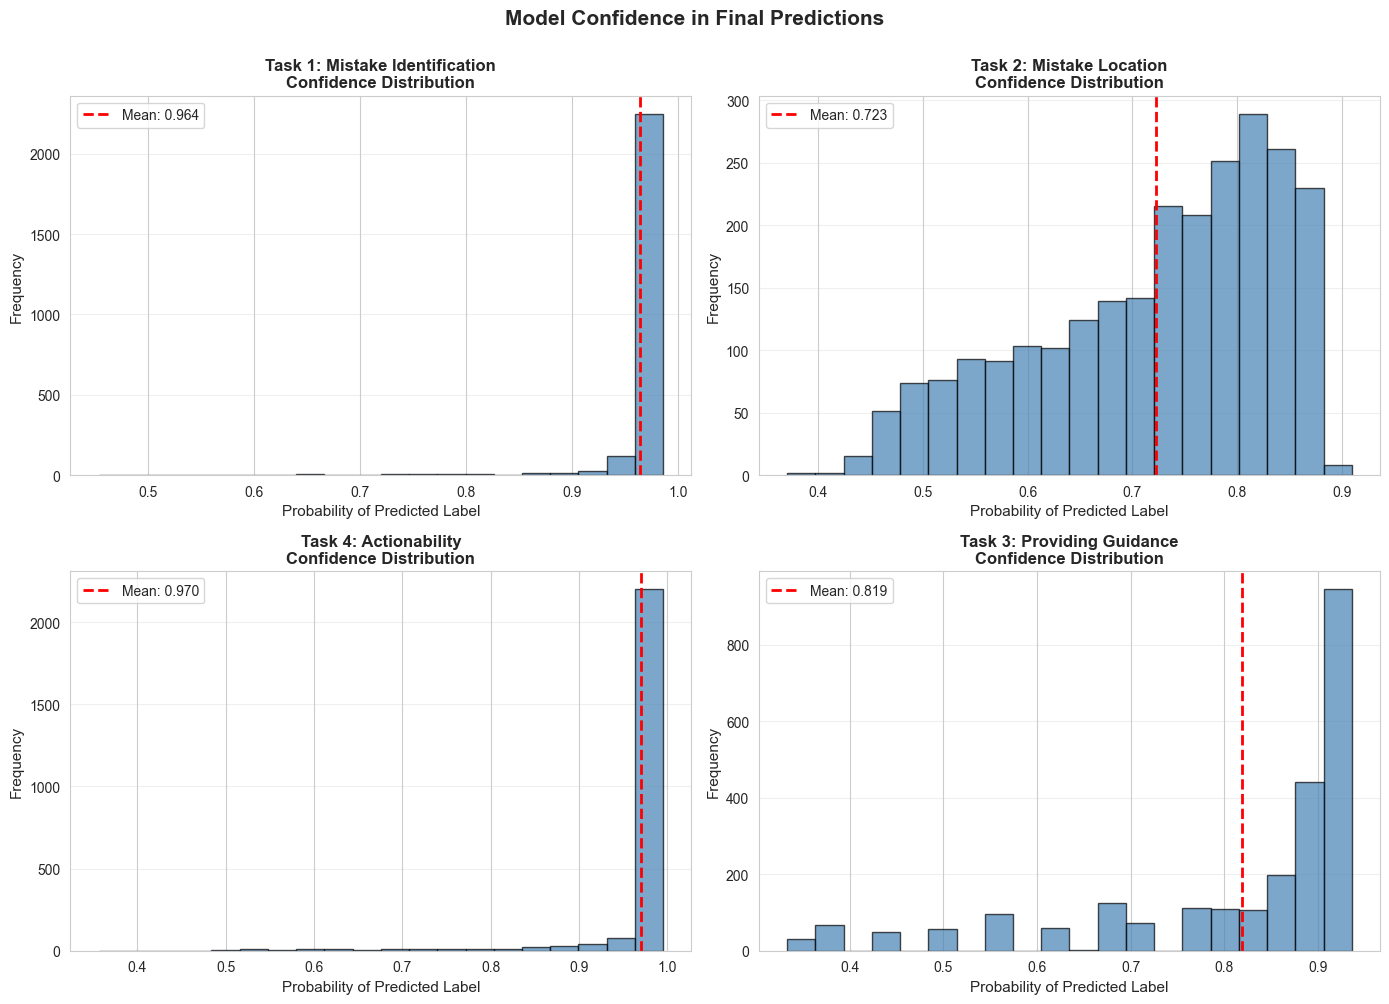

In [10]:
# Visualization: Probability distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

all_tasks = bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']
task_names_short = ['Task 1: Mistake Identification', 'Task 2: Mistake Location', 'Task 4: Actionability', 'Task 3: Providing Guidance']

for idx, (task, short_name) in enumerate(zip(all_tasks, task_names_short)):
    # Collect probabilities for the predicted label
    predicted_probs = []
    for conv in data:
        final_pred = conv['predictions']
        
        if task == 'Providing Guidance (should provide the student with relevant and helpful guidance)':
            if 'ialabuc_prediction' in final_pred:
                pred_label = final_pred['ialabuc_prediction']['predicted_label']
                prob = final_pred['ialabuc_prediction']['class_probabilities'][pred_label]
                predicted_probs.append(prob)
        else:
            if task in final_pred['bd_predictions']:
                pred_label = final_pred['bd_predictions'][task]['predicted_label']
                prob = final_pred['bd_predictions'][task]['probabilities'][pred_label]
                predicted_probs.append(prob)
    
    if predicted_probs:
        axes[idx].hist(predicted_probs, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].axvline(np.mean(predicted_probs), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {np.mean(predicted_probs):.3f}')
        axes[idx].set_xlabel('Probability of Predicted Label', fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].set_title(f'{short_name}\nConfidence Distribution', fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Model Confidence in Final Predictions', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 5. Model Comparison


In [11]:
# Analyze by model alias
model_stats = defaultdict(lambda: {'iterations': [], 'completed': []})

for conv in data:
    model = conv['model_alias']
    num_iters = len(conv['iterations'])
    completed = conv['completed']
    
    model_stats[model]['iterations'].append(num_iters)
    model_stats[model]['completed'].append(completed)

# Create summary table
model_summary = []
for model in sorted(model_stats.keys()):
    stats = model_stats[model]
    model_summary.append({
        'Model': model,
        'Count': len(stats['iterations']),
        'Avg Iterations': np.mean(stats['iterations']),
        'Completion Rate (%)': sum(stats['completed']) / len(stats['completed']) * 100
    })

model_df = pd.DataFrame(model_summary)
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(model_df.to_string(index=False))

MODEL COMPARISON
      Model  Count  Avg Iterations  Completion Rate (%)
     Expert    300        1.936667            88.000000
       GPT4    300        2.003333            82.666667
     Gemini    300        1.940000            84.000000
Llama31405B    300        1.660000            84.666667
  Llama318B    300        2.030000            83.000000
    Mistral    300        1.780000            85.666667
     Novice     76        2.171053            90.789474
       Phi3    300        2.323333            78.666667
     Sonnet    300        1.776667            86.666667


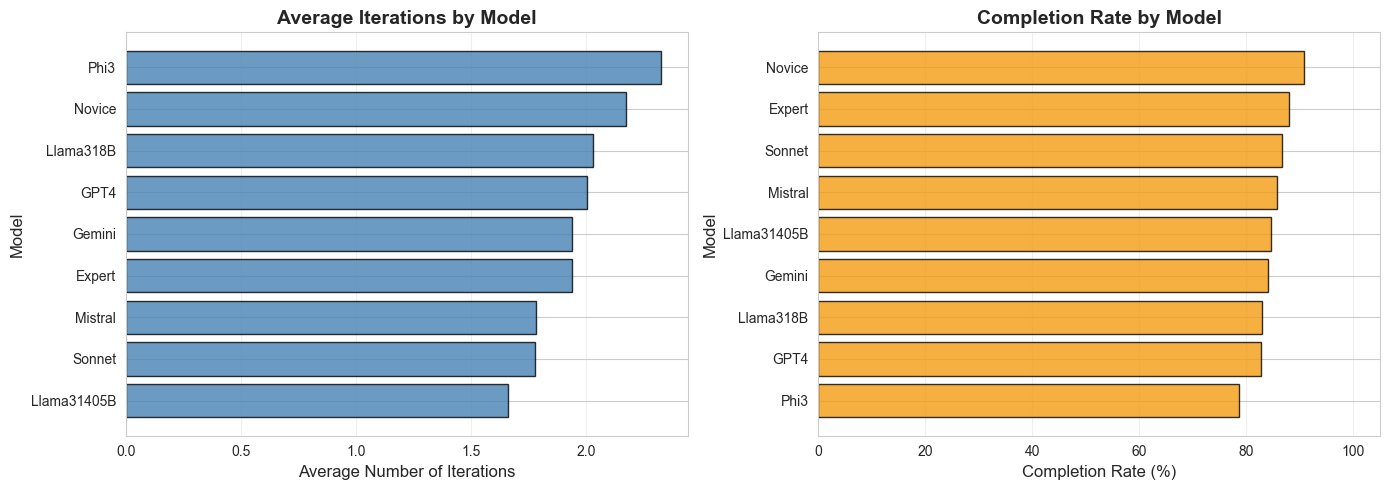

In [12]:
# Visualization: Model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average iterations by model (sorted by avg iterations)
model_df_sorted_iter = model_df.sort_values('Avg Iterations', ascending=True)
axes[0].barh(model_df_sorted_iter['Model'], model_df_sorted_iter['Avg Iterations'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Average Number of Iterations', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].set_title('Average Iterations by Model', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Completion rate by model (sorted by completion rate)
model_df_sorted_comp = model_df.sort_values('Completion Rate (%)', ascending=True)
colors_comp = ['#2ecc71' if rate == 100 else '#f39c12' for rate in model_df_sorted_comp['Completion Rate (%)']]
axes[1].barh(model_df_sorted_comp['Model'], model_df_sorted_comp['Completion Rate (%)'], color=colors_comp, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Completion Rate (%)', fontsize=12)
axes[1].set_ylabel('Model', fontsize=12)
axes[1].set_title('Completion Rate by Model', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 105)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary Report


In [13]:
# Generate comprehensive summary
print("=" * 80)
print(" " * 20 + "REFINEMENT PROCESS SUMMARY REPORT")
print("=" * 80)

print(f"\n{'Dataset:':<30} MRBench v3 DevSet Refinements")
print(f"{'Total Conversations:':<30} {len(data)}")
print(f"{'Unique Models:':<30} {len(model_stats)}")

print(f"\n{'ITERATION METRICS':-^80}")
print(f"{'Average Iterations:':<30} {np.mean(iteration_counts):.2f}")
print(f"{'Median Iterations:':<30} {np.median(iteration_counts):.0f}")
print(f"{'Iteration Range:':<30} {np.min(iteration_counts)} - {np.max(iteration_counts)}")

print(f"\n{'COMPLETION METRICS':-^80}")
completed = sum(completed_status)
print(f"{'Completed Refinements:':<30} {completed} ({completed/len(data)*100:.1f}%)")
print(f"{'Incomplete Refinements:':<30} {len(data)-completed} ({(len(data)-completed)/len(data)*100:.1f}%)")

print(f"\n{'LABEL DISTRIBUTION (FINAL)':-^80}")
for task in bd_tasks + ['Providing Guidance (should provide the student with relevant and helpful guidance)']:
    task_name = task.split('(')[0].strip() if '(' in task else task
    if final_predictions[task]:
        yes_count = sum(1 for l in final_predictions[task] if l == 'Yes')
        print(f"{task_name:<30} Yes: {yes_count/len(final_predictions[task])*100:.1f}%")

print(f"\n{'MODEL PERFORMANCE':-^80}")
for _, row in model_df.iterrows():
    print(f"{row['Model']:<15} | Avg Iter: {row['Avg Iterations']:.2f} | Completion: {row['Completion Rate (%)']:.1f}%")

print("\n" + "=" * 80)

                    REFINEMENT PROCESS SUMMARY REPORT

Dataset:                       MRBench v3 DevSet Refinements
Total Conversations:           2476
Unique Models:                 9

-------------------------------ITERATION METRICS--------------------------------
Average Iterations:            1.94
Median Iterations:             2
Iteration Range:               1 - 3

-------------------------------COMPLETION METRICS-------------------------------
Completed Refinements:         2089 (84.4%)
Incomplete Refinements:        387 (15.6%)

---------------------------LABEL DISTRIBUTION (FINAL)---------------------------
Mistake Identification         Yes: 97.9%
Mistake Location               Yes: 93.2%
Actionability                  Yes: 90.9%
Providing Guidance             Yes: 96.6%

-------------------------------MODEL PERFORMANCE--------------------------------
Expert          | Avg Iter: 1.94 | Completion: 88.0%
GPT4            | Avg Iter: 2.00 | Completion: 82.7%
Gemini          | Av